# Process Raw Chamber Data With Preprocessing

Load raw chamber measurements, map user-specific columns into the FCS schema, clean a protected working copy with general or ID-by-ID interpolation, optionally export the cleaned data and edit log, and run standard FCS processing with optional MCMC. Source CSV and JSON files are never modified.


## Setup


In [9]:
import pathlib
import sys
import urllib.parse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    display = print

CWD = pathlib.Path.cwd().resolve()
for candidate in [CWD, *CWD.parents]:
    if (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    REPO_ROOT = CWD

NOTEBOOK_DIR = REPO_ROOT / "notebooks" / "processing"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from soilgasflux_fcs import Multiprocessor, json_reader

DEFAULT_OUTPUT_DIR = NOTEBOOK_DIR / "output"
DEFAULT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CANONICAL_COLUMNS = [
    "datetime",
    "id",
    "timedelta",
    "k30_co2",
    "si_temperature",
    "si_humidity",
    "bmp_pressure",
]


EDITABLE_COLUMNS = {
    "k30_co2": {"label": "CO2", "unit": "ppm"},
    "bmp_pressure": {"label": "Pressure", "unit": "Pa"},
    "si_temperature": {"label": "Temperature", "unit": "C"},
    "si_humidity": {"label": "Relative humidity", "unit": "%"},
}

PROCESSING_REQUIRED_NONNULL_COLUMNS = [
    "datetime",
    "id",
    "timedelta",
    "k30_co2",
]
PROCESSING_OPTIONAL_ENVIRONMENT_COLUMNS = [
    "bmp_pressure",
    "si_temperature",
    "si_humidity",
]

AUDIT_COLUMNS = [
    "event_id",
    "timestamp_utc",
    "action",
    "mode",
    "target_column",
    "scope",
    "measurement_id",
    "lower_bound",
    "upper_bound",
    "affected_rows",
    "affected_ids",
    "affected_cells",
    "reverts_event_id",
]


## Loading And Normalization Helpers


In [10]:
def sanitize_input_path(input_path):
    text = str(input_path or "").strip()
    if not text:
        raise FileNotFoundError("Input path is empty. Paste a file or folder path before loading.")

    if text.startswith(("Path(", "pathlib.Path(")) and text.endswith(")"):
        text = text[text.find("(") + 1:-1].strip()

    for _ in range(2):
        if len(text) >= 2 and text[0] == text[-1] and text[0] in {"'", '"'}:
            text = text[1:-1].strip()

    if text.endswith("()"):
        text = text[:-2].strip()

    parsed = urllib.parse.urlparse(text)
    if parsed.scheme == "file":
        text = urllib.parse.unquote(parsed.path)

    if text.startswith("Users/"):
        text = "/" + text

    return pathlib.Path(text).expanduser()


def find_matching_folders(input_path, folder_name=None):
    root = sanitize_input_path(input_path)
    if not root.exists():
        raise FileNotFoundError(f"Input path does not exist: {root}")
    if not root.is_dir():
        if folder_name is None:
            return []
        raise NotADirectoryError(
            f"Folder filtering requires a root folder, not a file: {root}"
        )
    if folder_name is None:
        return [root]

    name = str(folder_name).strip()
    if not name:
        raise ValueError("Enter a folder name when 'Filter folder' is enabled.")
    if (
        name in {".", ".."}
        or any(character in name for character in ("/", "\\", "*", "?", "[", "]"))
    ):
        raise ValueError(
            "Folder filter must be one exact folder name without path separators or wildcards."
        )

    candidates = [root] if root.name == name else []
    candidates.extend(
        candidate
        for candidate in root.rglob("*")
        if candidate.is_dir() and candidate.name == name
    )
    if not candidates:
        raise FileNotFoundError(
            f"No folder named {name!r} was found under {root}."
        )

    matches = []
    for candidate in sorted(set(candidates), key=lambda item: (len(item.parts), str(item))):
        if any(parent == candidate or parent in candidate.parents for parent in matches):
            continue
        matches.append(candidate)
    return matches


def find_input_files(input_path, pattern="*.csv", folder_name=None):
    path = sanitize_input_path(input_path)
    if path.is_file():
        if folder_name is not None:
            raise NotADirectoryError(
                f"Folder filtering requires a root folder, not a file: {path}"
            )
        return [path]
    if path.is_dir():
        search_folders = find_matching_folders(path, folder_name)
        if folder_name is None:
            files = sorted(file for file in path.glob(pattern) if file.is_file())
        else:
            files = sorted({
                file
                for folder in search_folders
                for file in folder.rglob(pattern)
                if file.is_file()
            })
        if files:
            return files
        scope = path if folder_name is None else f"folders named {str(folder_name).strip()!r} under {path}"
        raise FileNotFoundError(
            f"No CSV files matched pattern {pattern!r} in {scope}. "
            "Check the input mode, folder filter, and CSV pattern."
        )
    raise FileNotFoundError(f"Input path does not exist: {path}")


def find_json_files(folder_path, min_size_bytes=5000, folder_name=None):
    folder = sanitize_input_path(folder_path)
    if not folder.exists():
        raise FileNotFoundError(f"JSON folder does not exist: {folder}")
    if not folder.is_dir():
        raise NotADirectoryError(f"JSON input must be a folder, not a file: {folder}")

    search_folders = find_matching_folders(folder, folder_name)
    all_json = sorted({
        file
        for search_folder in search_folders
        for file in search_folder.rglob("*.json")
        if file.is_file()
    })
    usable = [file for file in all_json if file.stat().st_size >= min_size_bytes]
    ignored = [file for file in all_json if file.stat().st_size < min_size_bytes]

    scope = folder if folder_name is None else f"folders named {str(folder_name).strip()!r} under {folder}"
    if not all_json:
        raise FileNotFoundError(f"No JSON files found in {scope}.")
    if not usable:
        raise FileNotFoundError(
            f"No usable JSON files found in {scope}. Found {len(all_json)} JSON file(s), "
            f"but all were smaller than {min_size_bytes} bytes."
        )
    return usable, ignored


def load_json_folder(folder_path, min_size_bytes=5000, folder_name=None):
    folder = sanitize_input_path(folder_path)
    search_folders = find_matching_folders(folder, folder_name)
    files, ignored = find_json_files(
        folder, min_size_bytes=min_size_bytes, folder_name=folder_name
    )
    frames = []
    try:
        for search_folder in search_folders:
            if not any(search_folder == file.parent or search_folder in file.parents for file in files):
                continue
            frames.append(json_reader.Initializer(search_folder).prepare_rawdata())
    except ValueError as exc:
        if "No objects to concatenate" in str(exc) or "no objects to concatenate" in str(exc):
            raise FileNotFoundError(
                f"No usable JSON raw-data files were loaded from {folder}. "
                "Check that the selected folders contain FCS JSON files with a raw_data section."
            ) from exc
        raise
    if not frames:
        raise FileNotFoundError(f"JSON files were found in {folder}, but no rows were loaded.")
    df = pd.concat(frames) if len(frames) > 1 else frames[0]
    df.sort_values(by="datetime", inplace=True)
    if df.empty:
        raise FileNotFoundError(f"JSON files were found in {folder}, but no rows were loaded.")
    df.attrs["source_path"] = str(folder)
    df.attrs["source_files"] = [str(file) for file in files]
    df.attrs["ignored_small_json_files"] = [str(file) for file in ignored]
    df.attrs["folder_filter"] = None if folder_name is None else str(folder_name).strip()
    df.attrs["matched_folders"] = (
        [] if folder_name is None else [str(search_folder) for search_folder in search_folders]
    )
    columns = CANONICAL_COLUMNS + [c for c in df.columns if c not in CANONICAL_COLUMNS]
    result = df[columns]
    result.attrs = df.attrs.copy()
    return result


def load_csv_files(input_path, pattern="*.csv", delimiter=",", folder_name=None):
    path = sanitize_input_path(input_path)
    files = find_input_files(path, pattern=pattern, folder_name=folder_name)
    frames = []
    for file in files:
        df = pd.read_csv(file, sep=delimiter)
        df["__source_file"] = file.stem
        frames.append(df)
    if not frames:
        raise FileNotFoundError(
            f"No CSV files could be read from {sanitize_input_path(input_path)} with pattern {pattern!r}."
        )
    raw = pd.concat(frames, ignore_index=True)
    raw.attrs["source_files"] = [str(file) for file in files]
    raw.attrs["folder_filter"] = None if folder_name is None else str(folder_name).strip()
    raw.attrs["matched_folders"] = (
        []
        if folder_name is None
        else [str(folder) for folder in find_matching_folders(path, folder_name)]
    )
    return raw


def guess_column(columns, candidates):
    normalized = {str(col).lower().strip(): col for col in columns}
    for candidate in candidates:
        key = candidate.lower().strip()
        if key in normalized:
            return normalized[key]
    for col in columns:
        lower = str(col).lower()
        if any(candidate.lower() in lower for candidate in candidates):
            return col
    return ""


def _require_or_fill(raw_df, source_col, output_col, fill_missing_environment, default_value):
    if source_col:
        return raw_df[source_col]
    if fill_missing_environment:
        return default_value
    raise ValueError(
        f"Missing mapping for {output_col}. Select a source column or enable constant-fill mode."
    )


def normalize_csv_dataframe(
    raw_df,
    *,
    co2_col,
    timestamp_col="",
    elapsed_col="",
    id_col="",
    pressure_col="",
    temperature_col="",
    humidity_col="",
    pressure_unit="Pa",
    fill_missing_environment=False,
    default_pressure_pa=101325.0,
    default_temperature_c=20.0,
    default_humidity_percent=70.0,
):
    if not co2_col:
        raise ValueError("CO2 column is required.")
    if not timestamp_col and not elapsed_col:
        raise ValueError("Select either a timestamp column or an elapsed-seconds column.")

    df = pd.DataFrame()
    if id_col:
        df["id"] = raw_df[id_col].astype(str)
    elif "__source_file" in raw_df.columns:
        df["id"] = raw_df["__source_file"].astype(str)
    else:
        df["id"] = "measurement_001"

    df["k30_co2"] = pd.to_numeric(raw_df[co2_col], errors="coerce")

    if timestamp_col:
        df["datetime"] = pd.to_datetime(raw_df[timestamp_col], errors="coerce")
        df["timedelta"] = (
            df.groupby("id")["datetime"]
            .transform(lambda values: (values - values.min()).dt.total_seconds())
            .astype("float")
        )
    else:
        df["timedelta"] = pd.to_numeric(raw_df[elapsed_col], errors="coerce")
        base = pd.Timestamp("2000-01-01")
        offsets = {measurement_id: n for n, measurement_id in enumerate(df["id"].drop_duplicates())}
        df["datetime"] = [
            base + pd.Timedelta(days=offsets[measurement_id]) + pd.Timedelta(seconds=float(seconds))
            if pd.notna(seconds) else pd.NaT
            for measurement_id, seconds in zip(df["id"], df["timedelta"])
        ]

    pressure = _require_or_fill(
        raw_df,
        pressure_col,
        "bmp_pressure",
        fill_missing_environment,
        default_pressure_pa,
    )
    pressure = pd.to_numeric(pressure, errors="coerce")
    if pressure_col and pressure_unit == "kPa":
        pressure = pressure * 1000.0
    df["bmp_pressure"] = pressure

    df["si_temperature"] = pd.to_numeric(
        _require_or_fill(
            raw_df,
            temperature_col,
            "si_temperature",
            fill_missing_environment,
            default_temperature_c,
        ),
        errors="coerce",
    )
    df["si_humidity"] = pd.to_numeric(
        _require_or_fill(
            raw_df,
            humidity_col,
            "si_humidity",
            fill_missing_environment,
            default_humidity_percent,
        ),
        errors="coerce",
    )

    df = df.sort_values(["id", "datetime", "timedelta"]).reset_index(drop=True)
    return df[CANONICAL_COLUMNS]


def validate_fcs_dataframe(df):
    missing = [column for column in CANONICAL_COLUMNS if column not in df.columns]
    null_counts = df[CANONICAL_COLUMNS].isna().sum().to_dict() if not missing else {}
    valid = not missing and all(count == 0 for count in null_counts.values())
    return {
        "valid": valid,
        "missing_columns": missing,
        "null_counts": null_counts,
        "n_measurements": int(df["id"].nunique()) if "id" in df.columns else 0,
        "n_rows": int(len(df)),
    }


def validate_processing_dataframe(df):
    """Allow environmental nulls while protecting FCS identity, time, and CO2."""
    missing = [column for column in CANONICAL_COLUMNS if column not in df.columns]
    null_counts = df[CANONICAL_COLUMNS].isna().sum().to_dict() if not missing else {}
    blocking_null_counts = (
        {column: int(null_counts[column]) for column in PROCESSING_REQUIRED_NONNULL_COLUMNS}
        if not missing
        else {}
    )
    allowed_environment_null_counts = (
        {column: int(null_counts[column]) for column in PROCESSING_OPTIONAL_ENVIRONMENT_COLUMNS}
        if not missing
        else {}
    )
    valid = not missing and all(
        count == 0 for count in blocking_null_counts.values()
    )
    return {
        "valid": valid,
        "missing_columns": missing,
        "null_counts": null_counts,
        "blocking_null_counts": blocking_null_counts,
        "allowed_environment_null_counts": allowed_environment_null_counts,
        "n_measurements": int(df["id"].nunique()) if "id" in df.columns else 0,
        "n_rows": int(len(df)),
    }


def summarize_measurements(df):
    summary = (
        df.groupby("id")
        .agg(
            n_rows=("timedelta", "size"),
            start=("datetime", "min"),
            end=("datetime", "max"),
            duration_s=("timedelta", "max"),
            min_co2=("k30_co2", "min"),
            max_co2=("k30_co2", "max"),
        )
        .reset_index()
    )
    return summary


def plot_measurement(df, measurement_id=None):
    measurement_id = measurement_id or df["id"].iloc[0]
    selected = df[df["id"].astype(str) == str(measurement_id)]
    fig, ax = plt.subplots(figsize=(7, 3.5), dpi=120)
    ax.plot(selected["timedelta"], selected["k30_co2"], color="#1f77b4", linewidth=1.8)
    ax.scatter(selected["timedelta"], selected["k30_co2"], color="#1f77b4", s=10, alpha=0.4)
    ax.set_xlabel("Elapsed time [s]")
    ax.set_ylabel(r"$CO_2$ [ppm]")
    ax.set_title(f"Measurement: {measurement_id}")
    fig.tight_layout()
    return fig


def run_fcs_processing(
    df,
    *,
    chamber_id,
    output_folder=DEFAULT_OUTPUT_DIR,
    area=314.0,
    volume=6283.0,
    use_mcmc=False,
    n_mc=500,
    sensor_precision=None,
):
    validation = validate_processing_dataframe(df)
    if not validation["valid"]:
        raise ValueError(f"Dataframe is not ready for FCS processing: {validation}")

    output_folder = pathlib.Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    processor = Multiprocessor()
    metadata = {"area": area, "volume": volume}
    if use_mcmc:
        return processor.run_MC(
            df=df,
            chamber_id=chamber_id,
            output_folder=str(output_folder),
            save_netcdf=True,
            sensor_precision=sensor_precision,
            n_MC=n_mc,
            metadata=metadata,
        )
    return processor.run(
        df=df,
        chamber_id=chamber_id,
        output_folder=str(output_folder),
        metadata=metadata,
    )



def _validate_editable_column(column):
    if column not in EDITABLE_COLUMNS:
        raise ValueError(
            f"Column {column!r} cannot be preprocessed. "
            f"Choose one of: {', '.join(EDITABLE_COLUMNS)}."
        )


def general_rejection_mask(df, column, lower, upper):
    _validate_editable_column(column)
    lower = float(lower)
    upper = float(upper)
    if not np.isfinite(lower) or not np.isfinite(upper):
        raise ValueError("Acceptable-range bounds must be finite numbers.")
    if lower > upper:
        raise ValueError("Acceptable-range minimum must be less than or equal to the maximum.")

    values = pd.to_numeric(df[column], errors="coerce")
    finite = pd.Series(np.isfinite(values.to_numpy(dtype=float)), index=df.index)
    return (~finite) | values.lt(lower) | values.gt(upper)


def manual_rejection_mask(df, measurement_id, start_s, end_s):
    start_s = float(start_s)
    end_s = float(end_s)
    if not np.isfinite(start_s) or not np.isfinite(end_s):
        raise ValueError("Elapsed-time bounds must be finite numbers.")
    if start_s > end_s:
        raise ValueError("Elapsed-time start must be less than or equal to the end.")

    id_mask = df["id"].astype(str).eq(str(measurement_id))
    if not id_mask.any():
        raise ValueError(f"Measurement ID {measurement_id!r} is not present in the working data.")

    elapsed = pd.to_numeric(df["timedelta"], errors="coerce")
    return id_mask & elapsed.between(start_s, end_s, inclusive="both")


def interpolate_rejected_values(df, column, rejection_mask):
    """Return a copy with masked values interpolated independently within each ID."""
    _validate_editable_column(column)
    mask = pd.Series(rejection_mask, index=df.index).fillna(False).astype(bool)
    if not mask.any():
        raise ValueError("The selected rule does not reject any rows.")

    candidate = df.copy(deep=True)
    affected_ids = candidate.loc[mask, "id"].astype(str).drop_duplicates().tolist()

    for measurement_id in affected_ids:
        group_indices = candidate.index[candidate["id"].astype(str).eq(measurement_id)]
        sorted_indices = (
            candidate.loc[group_indices]
            .sort_values(["timedelta", "datetime"], kind="mergesort")
            .index
        )
        rejected = mask.loc[sorted_indices].to_numpy(dtype=bool)
        if not rejected.any():
            continue

        elapsed = pd.to_numeric(
            candidate.loc[sorted_indices, "timedelta"], errors="coerce"
        ).to_numpy(dtype=float)
        values = pd.to_numeric(
            candidate.loc[sorted_indices, column], errors="coerce"
        ).to_numpy(dtype=float)

        if not np.isfinite(elapsed[rejected]).all():
            # raise ValueError(
            #     f"Cannot interpolate {column} for ID {measurement_id!r}: "
            #     "a rejected row has an invalid elapsed time."
            # )
            continue  # Skip this ID if any rejected row has invalid elapsed time.

        anchor_values = values.copy()
        anchor_values[rejected] = np.nan
        anchors = np.isfinite(elapsed) & np.isfinite(anchor_values)
        if not anchors.any():
            # raise ValueError(
            #     f"Cannot interpolate {column} for ID {measurement_id!r}: "
            #     "the operation would remove every valid anchor."
            # )
            continue  # Skip this ID if no valid anchors remain.

        # Collapse duplicate elapsed times to a single deterministic anchor.
        anchor_table = (
            pd.DataFrame({"elapsed": elapsed[anchors], "value": anchor_values[anchors]})
            .groupby("elapsed", sort=True, as_index=False)["value"]
            .mean()
        )
        filled = np.interp(
            elapsed[rejected],
            anchor_table["elapsed"].to_numpy(dtype=float),
            anchor_table["value"].to_numpy(dtype=float),
        )
        candidate.loc[sorted_indices[rejected], column] = filled

    changed_indices = candidate.index[mask]
    if not np.isfinite(
        pd.to_numeric(candidate.loc[changed_indices, column], errors="coerce")
        .to_numpy(dtype=float)
    ).all():
        raise ValueError("Interpolation left non-finite values in the selected rows.")

    return candidate


def build_preprocessing_preview(
    df,
    *,
    mode,
    column,
    lower,
    upper,
    measurement_id=None,
    plot_measurement_id=None,
):
    _validate_editable_column(column)
    if mode == "general":
        mask = general_rejection_mask(df, column, lower, upper)
        scope = "all_ids"
    elif mode == "manual":
        if measurement_id is None:
            raise ValueError("Select a measurement ID for ID-by-ID preprocessing.")
        mask = manual_rejection_mask(df, measurement_id, lower, upper)
        scope = "single_id"
    else:
        raise ValueError(f"Unknown preprocessing mode: {mode!r}")

    if not mask.any():
        raise ValueError("The selected rule does not reject any rows.")

    candidate = interpolate_rejected_values(df, column, mask)
    affected = (
        df.loc[mask]
        .groupby(df.loc[mask, "id"].astype(str), sort=False)
        .size()
        .rename("affected_rows")
        .reset_index()
        .rename(columns={"id": "measurement_id"})
    )
    affected_ids = affected["measurement_id"].astype(str).tolist()

    preferred_plot_id = measurement_id if mode == "manual" else plot_measurement_id
    if preferred_plot_id is not None and str(preferred_plot_id) in set(affected_ids):
        plot_id = str(preferred_plot_id)
    else:
        plot_id = affected_ids[0]

    return {
        "source": df,
        "candidate": candidate,
        "mask": mask,
        "mode": mode,
        "column": column,
        "lower": float(lower),
        "upper": float(upper),
        "scope": scope,
        "measurement_id": None if mode == "general" else str(measurement_id),
        "affected_rows": int(mask.sum()),
        "affected_ids": affected_ids,
        "summary": affected,
        "plot_id": plot_id,
    }


def build_sparse_delta(before, after, metadata=None):
    changes = {}
    affected_indices = set()

    for column in EDITABLE_COLUMNS:
        left = before[column]
        right = after[column]
        equal = left.eq(right) | (left.isna() & right.isna())
        indices = before.index[~equal]
        if len(indices):
            index_list = indices.tolist()
            changes[column] = {
                "indices": index_list,
                "before": before.loc[indices, column].tolist(),
                "after": after.loc[indices, column].tolist(),
            }
            affected_indices.update(index_list)

    if not changes:
        raise ValueError("This action would not change the working data.")

    affected_ids = (
        before.loc[sorted(affected_indices), "id"].astype(str).drop_duplicates().tolist()
    )
    return {
        "changes": changes,
        "metadata": dict(metadata or {}),
        "affected_rows": len(affected_indices),
        "affected_ids": affected_ids,
        "affected_cells": sum(len(change["indices"]) for change in changes.values()),
    }


def apply_sparse_delta(df, delta, direction):
    if direction not in {"before", "after"}:
        raise ValueError("Delta direction must be 'before' or 'after'.")

    result = df.copy(deep=True)
    for column, change in delta["changes"].items():
        result.loc[change["indices"], column] = change[direction]
    return result


def plot_preprocessing_preview(preview):
    source = preview["source"]
    candidate = preview["candidate"]
    measurement_id = preview["plot_id"]
    column = preview["column"]
    selected = source["id"].astype(str).eq(str(measurement_id))
    indices = source.index[selected]
    rejected = preview["mask"].reindex(indices, fill_value=False)

    metadata = EDITABLE_COLUMNS[column]
    fig, ax = plt.subplots(figsize=(8.2, 4.0), dpi=120)
    ax.plot(
        source.loc[indices, "timedelta"],
        source.loc[indices, column],
        color="#6b7280",
        linewidth=1.5,
        label="Current working values",
    )
    ax.plot(
        candidate.loc[indices, "timedelta"],
        candidate.loc[indices, column],
        color="#146c94",
        linewidth=2.0,
        linestyle="--",
        label="Preview after interpolation",
    )

    rejected_indices = indices[rejected.to_numpy(dtype=bool)]
    if len(rejected_indices):
        ax.scatter(
            source.loc[rejected_indices, "timedelta"],
            source.loc[rejected_indices, column],
            color="#c0392b",
            marker="x",
            s=42,
            linewidth=1.5,
            label="Rejected values",
            zorder=4,
        )

    if preview["mode"] == "manual":
        ax.axvspan(
            preview["lower"],
            preview["upper"],
            color="#f4a261",
            alpha=0.18,
            label="Selected elapsed-time interval",
        )
    else:
        ax.axhspan(
            preview["lower"],
            preview["upper"],
            color="#2a9d8f",
            alpha=0.10,
            label="Acceptable value range",
        )

    ax.set_xlabel("Elapsed time [s]")
    ax.set_ylabel(f"{metadata['label']} [{metadata['unit']}]")
    ax.set_title(f"Preprocessing preview: {measurement_id}")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


def export_preprocessed_data(
    df,
    audit_rows,
    output_folder,
    prefix="preprocessed",
):
    validation = validate_fcs_dataframe(df)
    if not validation["valid"]:
        raise ValueError(
            "The working dataframe must pass canonical validation before export: "
            f"{validation}"
        )

    folder = sanitize_input_path(output_folder)
    folder.mkdir(parents=True, exist_ok=True)

    safe_prefix = "".join(
        character if character.isalnum() or character in {"-", "_", "."} else "_"
        for character in str(prefix).strip()
    ).strip("._")
    if not safe_prefix:
        safe_prefix = "preprocessed"

    stamp = pd.Timestamp.now(tz="UTC").strftime("%Y%m%dT%H%M%S%fZ")
    suffix = ""
    counter = 1
    while True:
        data_path = folder / f"{safe_prefix}_{stamp}{suffix}.csv"
        audit_path = folder / f"{safe_prefix}_{stamp}{suffix}_edit_log.csv"
        if not data_path.exists() and not audit_path.exists():
            break
        suffix = f"_{counter}"
        counter += 1

    df.loc[:, CANONICAL_COLUMNS].to_csv(
        data_path,
        index=False,
        date_format="%Y-%m-%dT%H:%M:%S.%f",
    )
    pd.DataFrame(audit_rows, columns=AUDIT_COLUMNS).to_csv(audit_path, index=False)
    return data_path, audit_path


## Plain Python Example

Use these calls directly in scripts, or use the widget section below for the complete interactive workflow. The preprocessing helpers always return copies and never write to the source CSV or JSON files.


In [11]:
# JSON folder example
# raw = load_json_folder("/path/to/json/folder")
# normalized = normalize_csv_dataframe(
#     raw,
#     id_col="id",
#     timestamp_col="datetime",
#     co2_col="k30_co2",
#     pressure_col="bmp_pressure",
#     temperature_col="si_temperature",
#     humidity_col="si_humidity",
# )
#
# General acceptable-range example: keep CO2 values from 300 to 5000 ppm.
# preview = build_preprocessing_preview(
#     normalized,
#     mode="general",
#     column="k30_co2",
#     lower=300,
#     upper=5000,
# )
# working = preview["candidate"]
#
# ID-by-ID example: replace CO2 values from 20 through 30 elapsed seconds.
# preview = build_preprocessing_preview(
#     working,
#     mode="manual",
#     column="k30_co2",
#     measurement_id="measurement_001",
#     plot_measurement_id="measurement_001",
#     lower=20,
#     upper=30,
# )
# working = preview["candidate"]
# display(plot_preprocessing_preview(preview))


## Interactive Workflow


Output()

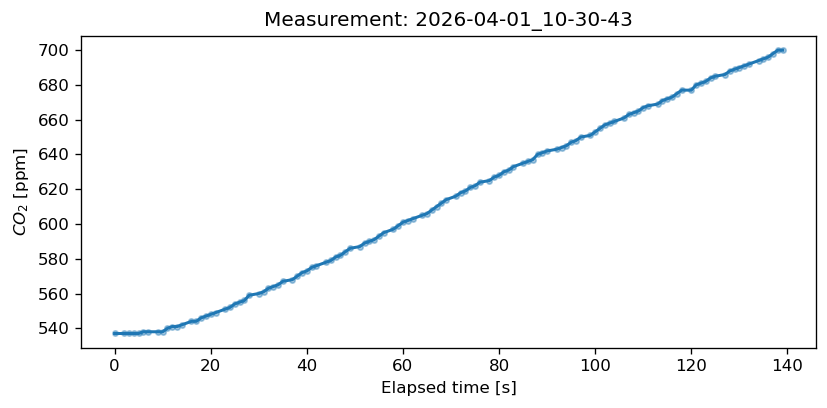

In [ ]:
import ipywidgets as widgets
from IPython.display import clear_output, display

state = {
    "raw": None,
    "normalized": None,
    "working": None,
    "preview": None,
    "history": [],
    "audit": [],
    "event_counter": 0,
    "revision": 0,
    "updating_controls": False,
}

style = {"description_width": "160px"}
wide = widgets.Layout(width="780px")
path_layout = widgets.Layout(width="780px", height="74px")
medium = widgets.Layout(width="380px")

input_mode_widget = widgets.Dropdown(
    options=["CSV", "JSON folder"],
    value="CSV",
    description="Input mode",
    style=style,
    layout=medium,
)
folder_filter_widget = widgets.Checkbox(
    value=False,
    description="Filter folder",
    indent=False,
    layout=widgets.Layout(width="140px"),
)
folder_name_widget = widgets.Text(
    value="",
    description="Folder name",
    placeholder="e.g. 1-1",
    continuous_update=False,
    disabled=True,
    style={"description_width": "95px"},
    layout=widgets.Layout(width="260px"),
)
input_path_widget = widgets.Textarea(
    value="",
    description="Input path",
    placeholder="Paste a file or folder path here",
    continuous_update=False,
    style=style,
    layout=path_layout,
)
current_path_widget = widgets.HTML(value="<b>Current path:</b> none")
pattern_widget = widgets.Text(
    value="*.csv",
    description="CSV pattern",
    continuous_update=False,
    style=style,
    layout=medium,
)
delimiter_widget = widgets.Text(
    value=",",
    description="CSV delimiter",
    continuous_update=False,
    style=style,
    layout=medium,
)

unloaded_option = [("Load input first", "")]
id_col_widget = widgets.Dropdown(
    options=unloaded_option,
    description="Measurement id",
    disabled=True,
    style=style,
    layout=medium,
)
timestamp_col_widget = widgets.Dropdown(
    options=unloaded_option,
    description="Timestamp",
    disabled=True,
    style=style,
    layout=medium,
)
elapsed_col_widget = widgets.Dropdown(
    options=unloaded_option,
    description="Elapsed seconds",
    disabled=True,
    style=style,
    layout=medium,
)
co2_col_widget = widgets.Dropdown(
    options=unloaded_option,
    description="CO2",
    disabled=True,
    style=style,
    layout=medium,
)
pressure_col_widget = widgets.Dropdown(
    options=unloaded_option,
    description="Pressure",
    disabled=True,
    style=style,
    layout=medium,
)
temperature_col_widget = widgets.Dropdown(
    options=unloaded_option,
    description="Temperature",
    disabled=True,
    style=style,
    layout=medium,
)
humidity_col_widget = widgets.Dropdown(
    options=unloaded_option,
    description="Humidity",
    disabled=True,
    style=style,
    layout=medium,
)
pressure_unit_widget = widgets.Dropdown(
    options=["Pa", "kPa"],
    value="Pa",
    description="Pressure unit",
    style=style,
    layout=medium,
)
fill_missing_widget = widgets.Checkbox(
    value=False,
    description="Allow constant environmental defaults",
    indent=False,
    layout=wide,
)
default_pressure_widget = widgets.FloatText(
    value=101325.0,
    description="Default pressure [Pa]",
    style=style,
    layout=medium,
)
default_temperature_widget = widgets.FloatText(
    value=20.0,
    description="Default temp [C]",
    style=style,
    layout=medium,
)
default_humidity_widget = widgets.FloatText(
    value=70.0,
    description="Default RH [%]",
    style=style,
    layout=medium,
)

mapping_status_widget = widgets.HTML(
    value="Load an input before selecting column mappings."
)

preprocess_status_widget = widgets.HTML(
    value="Normalize the data before preprocessing."
)
preprocess_mode_widget = widgets.ToggleButtons(
    options=[
        ("General acceptable range", "general"),
        ("ID-by-ID elapsed range", "manual"),
    ],
    value="general",
    description="Cleanup mode",
    style=style,
)
preprocess_column_widget = widgets.Dropdown(
    options=[],
    description="Signal",
    disabled=True,
    style=style,
    layout=widgets.Layout(width="430px"),
)
preprocess_id_widget = widgets.Dropdown(
    options=[],
    description="Measurement id",
    disabled=True,
    style=style,
    layout=widgets.Layout(width="430px"),
)
previous_id_button = widgets.Button(description="Previous ID", disabled=True)
next_id_button = widgets.Button(description="Next ID", disabled=True)

general_min_widget = widgets.FloatText(
    value=0.0,
    description="Acceptable minimum",
    disabled=True,
    style=style,
    layout=medium,
)
general_max_widget = widgets.FloatText(
    value=1.0,
    description="Acceptable maximum",
    disabled=True,
    style=style,
    layout=medium,
)

manual_range_widget = widgets.FloatRangeSlider(
    value=(0.0, 0.0),
    min=0.0,
    max=1.0,
    step=0.1,
    description="Elapsed range [s]",
    disabled=True,
    continuous_update=False,
    style=style,
    layout=widgets.Layout(width="780px"),
)
manual_start_widget = widgets.BoundedFloatText(
    value=0.0,
    min=0.0,
    max=1.0,
    description="Start [s]",
    disabled=True,
    style=style,
    layout=medium,
)
manual_end_widget = widgets.BoundedFloatText(
    value=0.0,
    min=0.0,
    max=1.0,
    description="End [s]",
    disabled=True,
    style=style,
    layout=medium,
)

preview_button = widgets.Button(
    description="Preview cleanup",
    button_style="info",
    disabled=True,
)
apply_preprocess_button = widgets.Button(
    description="Apply preview",
    button_style="success",
    disabled=True,
)
undo_button = widgets.Button(description="Undo last edit", disabled=True)
reset_id_button = widgets.Button(description="Reset selected ID", disabled=True)
reset_all_button = widgets.Button(description="Reset all", disabled=True)

preprocess_export_folder_widget = widgets.Textarea(
    value=str(DEFAULT_OUTPUT_DIR / "preprocessed"),
    description="Export folder",
    placeholder="Folder for cleaned CSV and edit log",
    continuous_update=False,
    style=style,
    layout=path_layout,
)
preprocess_export_prefix_widget = widgets.Text(
    value="preprocessed",
    description="File prefix",
    continuous_update=False,
    style=style,
    layout=medium,
)
export_preprocessed_button = widgets.Button(
    description="Export cleaned CSVs",
    button_style="primary",
    disabled=True,
)
preprocess_output = widgets.Output()

process_scope_widget = widgets.Dropdown(
    options=[
        ("Whole folder", "all"),
        ("Specific ID", "id"),
        ("Specific date", "date"),
    ],
    value="all",
    description="Processing scope",
    style=style,
    layout=widgets.Layout(width="430px"),
)
measurement_widget = widgets.Dropdown(
    options=[],
    description="Specific id",
    style=style,
    layout=widgets.Layout(width="430px", display="none"),
)
process_date_widget = widgets.Dropdown(
    options=[],
    description="Specific date",
    style=style,
    layout=widgets.Layout(width="430px", display="none"),
)
process_status_widget = widgets.HTML(
    value="Normalize the loaded data to populate processing targets."
)
chamber_id_widget = widgets.Text(
    value="analysis",
    description="Chamber id",
    continuous_update=False,
    style=style,
    layout=medium,
)
output_folder_widget = widgets.Textarea(
    value=str(DEFAULT_OUTPUT_DIR),
    description="Output folder",
    placeholder="Paste an output folder path here",
    continuous_update=False,
    style=style,
    layout=path_layout,
)
area_widget = widgets.FloatText(
    value=314.0,
    description="Area [cm2]",
    style=style,
    layout=medium,
)
volume_widget = widgets.FloatText(
    value=6283.0,
    description="Volume [cm3]",
    style=style,
    layout=medium,
)
use_mcmc_widget = widgets.Checkbox(
    value=False,
    description="Run MCMC",
    indent=False,
    layout=medium,
)
n_mc_widget = widgets.IntText(
    value=500,
    description="n_MC",
    style=style,
    layout=medium,
)
sensor_precision_widget = widgets.FloatText(
    value=np.nan,
    description="Sensor precision",
    style=style,
    layout=medium,
)

load_button = widgets.Button(description="Load input", button_style="primary")
normalize_button = widgets.Button(description="Normalize + preview", button_style="info")
process_button = widgets.Button(
    description="Run FCS",
    button_style="success",
    disabled=True,
)
workflow_output = widgets.Output()

column_widgets = [
    id_col_widget,
    timestamp_col_widget,
    elapsed_col_widget,
    co2_col_widget,
    pressure_col_widget,
    temperature_col_widget,
    humidity_col_widget,
]
normalization_widgets = column_widgets + [
    pressure_unit_widget,
    fill_missing_widget,
    default_pressure_widget,
    default_temperature_widget,
    default_humidity_widget,
]


def _show_error(exc):
    print(f"{type(exc).__name__}: {exc}")


def _clear_column_options():
    state["updating_controls"] = True
    try:
        for widget in column_widgets:
            widget.options = unloaded_option
            widget.value = ""
            widget.disabled = True
    finally:
        state["updating_controls"] = False
    mapping_status_widget.value = "Load an input before selecting column mappings."


def _set_column_options(columns):
    columns = list(columns)
    options = [""] + columns
    state["updating_controls"] = True
    try:
        for widget in column_widgets:
            widget.options = options
            widget.disabled = False

        id_col_widget.value = guess_column(
            columns, ["id", "measurement", "measurement_id", "chamber"]
        )
        timestamp_col_widget.value = guess_column(
            columns, ["timestamp", "datetime", "datetime_utc", "time"]
        )
        elapsed_col_widget.value = guess_column(
            columns, ["timedelta", "elapsed", "seconds", "time_s"]
        )
        co2_col_widget.value = guess_column(
            columns, ["co2", "k30_co2", "co2_ppm"]
        )
        pressure_col_widget.value = guess_column(
            columns, ["pressure", "bmp_pressure", "chamber_p"]
        )
        temperature_col_widget.value = guess_column(
            columns, ["temperature", "temp", "si_temperature", "chamber_t"]
        )
        humidity_col_widget.value = guess_column(
            columns, ["humidity", "rh", "si_humidity"]
        )
    finally:
        state["updating_controls"] = False
    mapping_status_widget.value = (
        f"Detected {len(columns)} columns. Review the mappings, then normalize the data."
    )


def _set_processing_scope_visibility(change=None):
    measurement_widget.layout.display = (
        "" if process_scope_widget.value == "id" else "none"
    )
    process_date_widget.layout.display = (
        "" if process_scope_widget.value == "date" else "none"
    )


def _preprocessing_mode_visibility(change=None):
    general_box.layout.display = (
        "" if preprocess_mode_widget.value == "general" else "none"
    )
    manual_box.layout.display = (
        "" if preprocess_mode_widget.value == "manual" else "none"
    )


def _working_change_count():
    if state["normalized"] is None or state["working"] is None:
        return 0
    count = 0
    for column in EDITABLE_COLUMNS:
        left = state["normalized"][column]
        right = state["working"][column]
        count += int((~(left.eq(right) | (left.isna() & right.isna()))).sum())
    return count


def _refresh_history_controls():
    ready = state["working"] is not None
    undo_button.disabled = not state["history"]
    reset_id_button.disabled = not ready or not preprocess_id_widget.options
    reset_all_button.disabled = not ready or _working_change_count() == 0
    export_preprocessed_button.disabled = (
        not ready or not validate_fcs_dataframe(state["working"])["valid"]
    )


def _refresh_processing_targets(df=None):
    state["updating_controls"] = True
    try:
        if df is None or df.empty:
            measurement_widget.options = []
            process_date_widget.options = []
            process_status_widget.value = (
                "Normalize the loaded data to populate processing targets."
            )
            process_button.disabled = True
        else:
            measurement_widget.options = sorted(df["id"].astype(str).unique())
            valid_dates = (
                df["datetime"].dropna().dt.strftime("%Y-%m-%d").drop_duplicates()
            )
            process_date_widget.options = sorted(valid_dates.tolist())
            validation = validate_processing_dataframe(df)
            process_button.disabled = not validation["valid"]
            if validation["valid"]:
                allowed_nulls = {
                    column: count
                    for column, count in validation["allowed_environment_null_counts"].items()
                    if count
                }
                ready_message = (
                    f"Ready: {len(df)} rows, {df['id'].nunique()} IDs, "
                    f"{df['datetime'].dt.date.nunique()} dates, "
                    f"{_working_change_count()} cleaned cells."
                )
                if allowed_nulls:
                    allowed_text = ", ".join(
                        f"{column}: {count}" for column, count in allowed_nulls.items()
                    )
                    ready_message += (
                        "<br><b>Warning:</b> Processing is allowed with environmental "
                        f"nulls that may be filled later ({allowed_text})."
                    )
                process_status_widget.value = ready_message
            else:
                process_status_widget.value = (
                    "Working data is not ready for FCS processing. "
                    f"Missing columns: {validation['missing_columns']}; "
                    f"blocking null counts: {validation['blocking_null_counts']}."
                )
    finally:
        state["updating_controls"] = False
    _set_processing_scope_visibility()
    _refresh_history_controls()


def _set_general_bounds_from_working():
    if state["working"] is None or not preprocess_column_widget.value:
        return
    values = pd.to_numeric(
        state["working"][preprocess_column_widget.value], errors="coerce"
    )
    values = values[np.isfinite(values)]
    if values.empty:
        preprocess_status_widget.value = (
            "The selected signal has no finite values from which to initialize bounds."
        )
        return

    state["updating_controls"] = True
    try:
        unit = EDITABLE_COLUMNS[preprocess_column_widget.value]["unit"]
        general_min_widget.description = f"Acceptable min [{unit}]"
        general_max_widget.description = f"Acceptable max [{unit}]"
        general_min_widget.value = float(values.min())
        general_max_widget.value = float(values.max())
    finally:
        state["updating_controls"] = False


def _set_manual_bounds_from_id():
    if (
        state["working"] is None
        or not preprocess_id_widget.value
        or not preprocess_id_widget.options
    ):
        return

    selected = state["working"][
        state["working"]["id"].astype(str).eq(str(preprocess_id_widget.value))
    ]
    elapsed = pd.to_numeric(selected["timedelta"], errors="coerce")
    elapsed = elapsed[np.isfinite(elapsed)]
    if elapsed.empty:
        preprocess_status_widget.value = (
            f"ID {preprocess_id_widget.value!r} has no finite elapsed times."
        )
        return

    lower = float(elapsed.min())
    upper = float(elapsed.max())
    display_upper = upper if upper > lower else lower + 1.0
    step = max((display_upper - lower) / 500.0, 0.001)

    state["updating_controls"] = True
    try:
        manual_range_widget.min = min(manual_range_widget.min, lower)
        manual_range_widget.max = max(manual_range_widget.max, display_upper)
        manual_range_widget.value = (lower, lower)
        manual_range_widget.min = lower
        manual_range_widget.max = display_upper
        manual_range_widget.step = step

        for widget in [manual_start_widget, manual_end_widget]:
            widget.min = min(widget.min, lower)
            widget.max = max(widget.max, upper)
            widget.value = lower
            widget.min = lower
            widget.max = upper
    finally:
        state["updating_controls"] = False


def _clear_preprocessing_controls():
    state["updating_controls"] = True
    try:
        preprocess_column_widget.options = []
        preprocess_column_widget.disabled = True
        preprocess_id_widget.options = []
        preprocess_id_widget.disabled = True
        previous_id_button.disabled = True
        next_id_button.disabled = True
        general_min_widget.disabled = True
        general_max_widget.disabled = True
        manual_range_widget.disabled = True
        manual_start_widget.disabled = True
        manual_end_widget.disabled = True
        preview_button.disabled = True
        apply_preprocess_button.disabled = True
    finally:
        state["updating_controls"] = False
    preprocess_status_widget.value = "Normalize the data before preprocessing."


def _refresh_preprocessing_controls(df=None):
    if df is None or df.empty:
        _clear_preprocessing_controls()
        _refresh_history_controls()
        return

    column_options = [
        (
            f"{metadata['label']} [{metadata['unit']}]",
            column,
        )
        for column, metadata in EDITABLE_COLUMNS.items()
    ]
    ids = sorted(df["id"].astype(str).unique())

    state["updating_controls"] = True
    try:
        current_column = preprocess_column_widget.value
        preprocess_column_widget.options = column_options
        if current_column not in EDITABLE_COLUMNS:
            preprocess_column_widget.value = "k30_co2"
        preprocess_column_widget.disabled = False

        current_id = preprocess_id_widget.value
        preprocess_id_widget.options = ids
        if current_id not in ids and ids:
            preprocess_id_widget.value = ids[0]
        preprocess_id_widget.disabled = not ids
        previous_id_button.disabled = len(ids) < 2
        next_id_button.disabled = len(ids) < 2

        general_min_widget.disabled = False
        general_max_widget.disabled = False
        manual_range_widget.disabled = not ids
        manual_start_widget.disabled = not ids
        manual_end_widget.disabled = not ids
        preview_button.disabled = False
    finally:
        state["updating_controls"] = False

    _set_general_bounds_from_working()
    _set_manual_bounds_from_id()
    preprocess_status_widget.value = (
        f"Working copy ready: {len(df)} rows and {df['id'].nunique()} IDs. "
        "Choose a cleanup mode and preview it."
    )
    _refresh_history_controls()


def _invalidate_preview(change=None, message=None):
    if state["updating_controls"]:
        return
    state["preview"] = None
    apply_preprocess_button.disabled = True
    if state["working"] is not None:
        preprocess_status_widget.value = (
            message or "Settings changed. Preview the cleanup again before applying."
        )


def _reset_derived_state():
    state["normalized"] = None
    state["working"] = None
    state["preview"] = None
    state["history"] = []
    state["audit"] = []
    state["event_counter"] = 0
    state["revision"] += 1
    _clear_preprocessing_controls()
    _refresh_processing_targets()


def _invalidate_normalized_data(change=None):
    if state["updating_controls"]:
        return
    _reset_derived_state()
    if state["raw"] is not None:
        mapping_status_widget.value = (
            "Mappings changed. Normalize again before preprocessing or FCS."
        )


def _invalidate_loaded_input(change=None):
    if state["updating_controls"]:
        return
    state["raw"] = None
    _clear_column_options()
    _reset_derived_state()
    current_path_widget.value = "<b>Current path:</b> settings changed; load input again"


def _on_folder_filter_toggled(change):
    folder_name_widget.disabled = not bool(change["new"])
    _invalidate_loaded_input(change)


def _select_processing_dataframe(df, scope, measurement_id=None, date=None):
    if scope == "all":
        selected = df.copy()
    elif scope == "id":
        if not measurement_id:
            raise ValueError("Select a measurement ID before running FCS.")
        selected = df[df["id"].astype(str).eq(str(measurement_id))].copy()
    elif scope == "date":
        if not date:
            raise ValueError("Select a date before running FCS.")
        selected = df[df["datetime"].dt.strftime("%Y-%m-%d").eq(str(date))].copy()
    else:
        raise ValueError(f"Unknown processing scope: {scope!r}")

    if selected.empty:
        raise ValueError(
            "The selected processing scope contains no rows. "
            "Normalize again and choose an available target."
        )
    return selected


def _processing_scope_label(scope, measurement_id=None, date=None):
    if scope == "id":
        return f"Specific ID: {measurement_id}"
    if scope == "date":
        return f"Specific date: {date}"
    return "Whole folder"


def _next_event_id():
    state["event_counter"] += 1
    return state["event_counter"]


def _audit_event(
    *,
    action,
    delta=None,
    mode="",
    target_column="",
    scope="",
    measurement_id="",
    lower_bound=np.nan,
    upper_bound=np.nan,
    reverts_event_id="",
):
    event_id = _next_event_id()
    row = {
        "event_id": event_id,
        "timestamp_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "action": action,
        "mode": mode,
        "target_column": target_column,
        "scope": scope,
        "measurement_id": measurement_id,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "affected_rows": 0 if delta is None else delta["affected_rows"],
        "affected_ids": 0 if delta is None else len(delta["affected_ids"]),
        "affected_cells": 0 if delta is None else delta["affected_cells"],
        "reverts_event_id": reverts_event_id,
    }
    state["audit"].append(row)
    return event_id


def _commit_delta(after, delta, audit_kwargs):
    event_id = _audit_event(delta=delta, **audit_kwargs)
    delta["event_id"] = event_id
    state["history"].append(delta)
    state["working"] = after
    state["preview"] = None
    state["revision"] += 1
    apply_preprocess_button.disabled = True
    _refresh_preprocessing_controls(state["working"])
    _refresh_processing_targets(state["working"])
    return event_id


def _display_current_measurement(clear=True):
    if (
        state["working"] is None
        or not preprocess_id_widget.value
        or not preprocess_column_widget.value
    ):
        return

    column = preprocess_column_widget.value
    measurement_id = preprocess_id_widget.value
    selected = state["working"][
        state["working"]["id"].astype(str).eq(str(measurement_id))
    ]
    metadata = EDITABLE_COLUMNS[column]

    with preprocess_output:
        if clear:
            clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8.2, 4.0), dpi=120)
        ax.plot(
            selected["timedelta"],
            selected[column],
            color="#146c94",
            linewidth=1.8,
        )
        ax.scatter(
            selected["timedelta"],
            selected[column],
            color="#146c94",
            s=12,
            alpha=0.45,
        )
        ax.set_xlabel("Elapsed time [s]")
        ax.set_ylabel(f"{metadata['label']} [{metadata['unit']}]")
        ax.set_title(f"Current working values: {measurement_id}")
        fig.tight_layout()
        display(fig)
        plt.close(fig)


def _on_preprocess_column_changed(change=None):
    if state["updating_controls"] or state["working"] is None:
        return
    _set_general_bounds_from_working()
    _invalidate_preview(message="Signal changed. Preview the cleanup again.")
    _display_current_measurement()


def _on_preprocess_id_changed(change=None):
    if state["updating_controls"] or state["working"] is None:
        return
    _set_manual_bounds_from_id()
    _invalidate_preview(message="Measurement ID changed. Preview the cleanup again.")
    _display_current_measurement()
    _refresh_history_controls()


def _on_preprocess_mode_changed(change=None):
    _preprocessing_mode_visibility()
    _invalidate_preview()
    if preprocess_mode_widget.value == "manual":
        _display_current_measurement()


def _move_preprocess_id(offset):
    options = list(preprocess_id_widget.options)
    if not options:
        return
    current = preprocess_id_widget.value
    index = options.index(current) if current in options else 0
    preprocess_id_widget.value = options[(index + offset) % len(options)]


def _sync_manual_text_from_slider(change=None):
    if state["updating_controls"]:
        return
    state["updating_controls"] = True
    try:
        manual_start_widget.value = float(manual_range_widget.value[0])
        manual_end_widget.value = float(manual_range_widget.value[1])
    finally:
        state["updating_controls"] = False
    _invalidate_preview()


def _sync_manual_slider_from_text(change=None):
    if state["updating_controls"]:
        return
    start = float(manual_start_widget.value)
    end = float(manual_end_widget.value)
    state["updating_controls"] = True
    try:
        if start > end:
            if change is not None and change.get("owner") is manual_start_widget:
                end = start
                manual_end_widget.value = end
            else:
                start = end
                manual_start_widget.value = start
        manual_range_widget.value = (start, end)
    finally:
        state["updating_controls"] = False
    _invalidate_preview()


def on_load_clicked(_):
    with workflow_output:
        clear_output(wait=True)
        try:
            state["raw"] = None
            _clear_column_options()
            _reset_derived_state()

            path = sanitize_input_path(input_path_widget.value)
            folder_name = folder_name_widget.value if folder_filter_widget.value else None

            if input_mode_widget.value == "JSON folder":
                files, ignored = find_json_files(path, folder_name=folder_name)
                raw = load_json_folder(path, folder_name=folder_name)
                matched_count = len(raw.attrs.get("matched_folders", []))
                if folder_name is None:
                    print(f"Matched {len(files)} usable JSON file(s) in {path}.")
                else:
                    print(
                        f"Matched {len(files)} usable JSON file(s) across "
                        f"{matched_count} folder(s) named {folder_name.strip()!r}."
                    )
                if ignored:
                    print(f"Ignored {len(ignored)} small JSON file(s).")
            else:
                files = find_input_files(
                    path, pattern=pattern_widget.value, folder_name=folder_name
                )
                raw = load_csv_files(
                    path,
                    pattern=pattern_widget.value,
                    delimiter=delimiter_widget.value,
                    folder_name=folder_name,
                )
                matched_count = len(raw.attrs.get("matched_folders", []))
                if folder_name is None:
                    print(f"Matched {len(files)} CSV file(s) in {path}.")
                else:
                    print(
                        f"Matched {len(files)} CSV file(s) across "
                        f"{matched_count} folder(s) named {folder_name.strip()!r}."
                    )

            if folder_name is None:
                current_path_widget.value = f"<b>Current path:</b> {path}"
            else:
                current_path_widget.value = (
                    f"<b>Current path:</b> {path}<br>"
                    f"<b>Folder filter:</b> {folder_name.strip()} "
                    f"({matched_count} matching folder(s))"
                )

            state["raw"] = raw
            _set_column_options(raw.columns)
            display(raw.head())
            if input_mode_widget.value == "JSON folder":
                display(summarize_measurements(raw))
            print(f"Detected {len(raw.columns)} columns and {len(raw)} rows.")
            print("Review the mappings in the Map Columns tab, then normalize.")
        except Exception as exc:
            _show_error(exc)


def on_normalize_clicked(_):
    with workflow_output:
        clear_output(wait=True)
        try:
            if state["raw"] is None:
                raise ValueError("Load input before normalizing.")

            df = normalize_csv_dataframe(
                state["raw"],
                id_col=id_col_widget.value,
                timestamp_col=timestamp_col_widget.value,
                elapsed_col=elapsed_col_widget.value,
                co2_col=co2_col_widget.value,
                pressure_col=pressure_col_widget.value,
                temperature_col=temperature_col_widget.value,
                humidity_col=humidity_col_widget.value,
                pressure_unit=pressure_unit_widget.value,
                fill_missing_environment=fill_missing_widget.value,
                default_pressure_pa=default_pressure_widget.value,
                default_temperature_c=default_temperature_widget.value,
                default_humidity_percent=default_humidity_widget.value,
            )
            state["normalized"] = df.copy(deep=True)
            state["working"] = df.copy(deep=True)
            state["preview"] = None
            state["history"] = []
            state["audit"] = []
            state["event_counter"] = 0
            state["revision"] += 1

            _refresh_preprocessing_controls(state["working"])
            _refresh_processing_targets(state["working"])
            mapping_status_widget.value = (
                "Normalization complete. The protected working copy is ready."
            )

            validation = validate_processing_dataframe(state["working"])
            display(state["working"].head())
            display(summarize_measurements(state["working"]))
            display(validation)
            if len(preprocess_id_widget.options):
                display(plot_measurement(state["working"], preprocess_id_widget.value))
        except Exception as exc:
            _show_error(exc)


def on_preview_clicked(_):
    with preprocess_output:
        clear_output(wait=True)
        try:
            if state["working"] is None:
                raise ValueError("Normalize data before preprocessing.")

            mode = preprocess_mode_widget.value
            if mode == "general":
                lower = general_min_widget.value
                upper = general_max_widget.value
                measurement_id = None
            else:
                lower = manual_start_widget.value
                upper = manual_end_widget.value
                measurement_id = preprocess_id_widget.value

            preview = build_preprocessing_preview(
                state["working"],
                mode=mode,
                column=preprocess_column_widget.value,
                lower=lower,
                upper=upper,
                measurement_id=measurement_id,
                plot_measurement_id=preprocess_id_widget.value,
            )
            preview["revision"] = state["revision"]
            state["preview"] = preview
            apply_preprocess_button.disabled = False
            preprocess_status_widget.value = (
                f"Preview ready: {preview['affected_rows']} rows across "
                f"{len(preview['affected_ids'])} ID(s). Review it, then apply."
            )

            display(preview["summary"])
            fig = plot_preprocessing_preview(preview)
            display(fig)
            plt.close(fig)
        except Exception as exc:
            state["preview"] = None
            apply_preprocess_button.disabled = True
            _show_error(exc)


def on_apply_preprocess_clicked(_):
    with preprocess_output:
        clear_output(wait=True)
        try:
            preview = state["preview"]
            if preview is None:
                raise ValueError("Create a preprocessing preview before applying.")
            if preview["revision"] != state["revision"]:
                raise ValueError("The working data changed. Preview the cleanup again.")

            before = state["working"]
            after = preview["candidate"]
            delta = build_sparse_delta(
                before,
                after,
                metadata={
                    "mode": preview["mode"],
                    "target_column": preview["column"],
                    "scope": preview["scope"],
                    "measurement_id": preview["measurement_id"] or "",
                    "lower_bound": preview["lower"],
                    "upper_bound": preview["upper"],
                },
            )
            event_id = _commit_delta(
                after,
                delta,
                {
                    "action": "apply",
                    "mode": preview["mode"],
                    "target_column": preview["column"],
                    "scope": preview["scope"],
                    "measurement_id": preview["measurement_id"] or "",
                    "lower_bound": preview["lower"],
                    "upper_bound": preview["upper"],
                },
            )
            print(
                f"Applied event {event_id}: {delta['affected_cells']} cells in "
                f"{delta['affected_rows']} rows across {len(delta['affected_ids'])} ID(s)."
            )
            fig = plot_preprocessing_preview(preview)
            display(fig)
            plt.close(fig)
        except Exception as exc:
            _show_error(exc)


def on_undo_clicked(_):
    with preprocess_output:
        clear_output(wait=True)
        try:
            if not state["history"]:
                raise ValueError("There is no preprocessing edit to undo.")

            delta = state["history"].pop()
            state["working"] = apply_sparse_delta(
                state["working"], delta, direction="before"
            )
            metadata = delta.get("metadata", {})
            undo_event_id = _audit_event(
                action="undo",
                delta=delta,
                mode=metadata.get("mode", ""),
                target_column=metadata.get("target_column", ""),
                scope=metadata.get("scope", ""),
                measurement_id=metadata.get("measurement_id", ""),
                lower_bound=metadata.get("lower_bound", np.nan),
                upper_bound=metadata.get("upper_bound", np.nan),
                reverts_event_id=delta.get("event_id", ""),
            )
            state["preview"] = None
            state["revision"] += 1
            _refresh_preprocessing_controls(state["working"])
            _refresh_processing_targets(state["working"])
            print(
                f"Undo event {undo_event_id} restored "
                f"{delta['affected_cells']} cells from event {delta.get('event_id')}."
            )
            _display_current_measurement(clear=False)
        except Exception as exc:
            _show_error(exc)


def _reset_to_baseline(measurement_id=None):
    if state["working"] is None or state["normalized"] is None:
        raise ValueError("Normalize data before resetting preprocessing.")

    before = state["working"]
    after = before.copy(deep=True)
    if measurement_id is None:
        mask = pd.Series(True, index=after.index)
        action = "reset_all"
        scope = "all_ids"
        measurement_label = ""
    else:
        mask = after["id"].astype(str).eq(str(measurement_id))
        action = "reset_id"
        scope = "single_id"
        measurement_label = str(measurement_id)

    for column in EDITABLE_COLUMNS:
        after.loc[mask, column] = state["normalized"].loc[mask, column]

    delta = build_sparse_delta(
        before,
        after,
        metadata={
            "mode": "reset",
            "target_column": "all_editable_signals",
            "scope": scope,
            "measurement_id": measurement_label,
            "lower_bound": np.nan,
            "upper_bound": np.nan,
        },
    )
    event_id = _commit_delta(
        after,
        delta,
        {
            "action": action,
            "mode": "reset",
            "target_column": "all_editable_signals",
            "scope": scope,
            "measurement_id": measurement_label,
        },
    )
    return event_id, delta


def on_reset_id_clicked(_):
    with preprocess_output:
        clear_output(wait=True)
        try:
            event_id, delta = _reset_to_baseline(preprocess_id_widget.value)
            print(
                f"Reset event {event_id} restored {delta['affected_cells']} cells "
                f"for ID {preprocess_id_widget.value}."
            )
            _display_current_measurement(clear=False)
        except Exception as exc:
            _show_error(exc)


def on_reset_all_clicked(_):
    with preprocess_output:
        clear_output(wait=True)
        try:
            event_id, delta = _reset_to_baseline()
            print(
                f"Reset event {event_id} restored {delta['affected_cells']} cells "
                "across the working copy."
            )
            _display_current_measurement(clear=False)
        except Exception as exc:
            _show_error(exc)


def on_export_preprocessed_clicked(_):
    with preprocess_output:
        clear_output(wait=True)
        try:
            if state["working"] is None:
                raise ValueError("Normalize data before exporting.")
            data_path, audit_path = export_preprocessed_data(
                state["working"],
                state["audit"],
                preprocess_export_folder_widget.value,
                prefix=preprocess_export_prefix_widget.value,
            )
            print("Preprocessed working copy exported without changing source files.")
            print(f"Data CSV: {data_path}")
            print(f"Edit log CSV: {audit_path}")
        except Exception as exc:
            _show_error(exc)


def on_process_clicked(_):
    with workflow_output:
        clear_output(wait=True)
        try:
            if state["working"] is None:
                raise ValueError("Normalize data before running FCS.")

            processing_df = _select_processing_dataframe(
                state["working"],
                process_scope_widget.value,
                measurement_id=measurement_widget.value,
                date=process_date_widget.value,
            )
            validation = validate_processing_dataframe(processing_df)
            if not validation["valid"]:
                raise ValueError(
                    f"Selected working data is not ready for FCS processing: {validation}"
                )

            allowed_nulls = {
                column: count
                for column, count in validation["allowed_environment_null_counts"].items()
                if count
            }
            if allowed_nulls:
                allowed_text = ", ".join(
                    f"{column}: {count}" for column, count in allowed_nulls.items()
                )
                print(
                    "Warning: continuing with environmental nulls that may be "
                    f"filled later ({allowed_text})."
                )

            selected_dates = sorted(
                processing_df["datetime"].dt.strftime("%Y-%m-%d").unique()
            )
            print(
                "Processing scope: "
                f"{_processing_scope_label(process_scope_widget.value, measurement_widget.value, process_date_widget.value)}"
            )
            print(
                f"Selected {len(processing_df)} rows, "
                f"{processing_df['id'].nunique()} IDs, "
                f"dates: {', '.join(selected_dates)}"
            )
            print(
                f"FCS is using the protected working copy with "
                f"{_working_change_count()} cleaned cells."
            )

            sensor_precision = (
                None
                if np.isnan(sensor_precision_widget.value)
                else sensor_precision_widget.value
            )
            result = run_fcs_processing(
                processing_df,
                chamber_id=chamber_id_widget.value,
                output_folder=output_folder_widget.value,
                area=area_widget.value,
                volume=volume_widget.value,
                use_mcmc=use_mcmc_widget.value,
                n_mc=n_mc_widget.value,
                sensor_precision=sensor_precision,
            )
            print("FCS processing complete.")
            print(f"Output folder: {output_folder_widget.value}")
            display(result)
        except Exception as exc:
            _show_error(exc)


load_button.on_click(on_load_clicked)
normalize_button.on_click(on_normalize_clicked)
preview_button.on_click(on_preview_clicked)
apply_preprocess_button.on_click(on_apply_preprocess_clicked)
undo_button.on_click(on_undo_clicked)
reset_id_button.on_click(on_reset_id_clicked)
reset_all_button.on_click(on_reset_all_clicked)
export_preprocessed_button.on_click(on_export_preprocessed_clicked)
process_button.on_click(on_process_clicked)

previous_id_button.on_click(lambda _: _move_preprocess_id(-1))
next_id_button.on_click(lambda _: _move_preprocess_id(1))

process_scope_widget.observe(_set_processing_scope_visibility, names="value")
preprocess_mode_widget.observe(_on_preprocess_mode_changed, names="value")
preprocess_column_widget.observe(_on_preprocess_column_changed, names="value")
preprocess_id_widget.observe(_on_preprocess_id_changed, names="value")
general_min_widget.observe(_invalidate_preview, names="value")
general_max_widget.observe(_invalidate_preview, names="value")
manual_range_widget.observe(_sync_manual_text_from_slider, names="value")
manual_start_widget.observe(_sync_manual_slider_from_text, names="value")
manual_end_widget.observe(_sync_manual_slider_from_text, names="value")

for widget in normalization_widgets:
    widget.observe(_invalidate_normalized_data, names="value")
for widget in [
    input_mode_widget,
    input_path_widget,
    folder_name_widget,
    pattern_widget,
    delimiter_widget,
]:
    widget.observe(_invalidate_loaded_input, names="value")
folder_filter_widget.observe(_on_folder_filter_toggled, names="value")

input_controls = widgets.VBox(
    [
        widgets.HBox([input_mode_widget, folder_filter_widget, folder_name_widget]),
        input_path_widget,
        current_path_widget,
        widgets.HBox([pattern_widget, delimiter_widget]),
        widgets.HBox([load_button, normalize_button]),
    ]
)

mapping_controls = widgets.VBox(
    [
        mapping_status_widget,
        widgets.HBox([id_col_widget, timestamp_col_widget]),
        widgets.HBox([elapsed_col_widget, co2_col_widget]),
        widgets.HBox([pressure_col_widget, pressure_unit_widget]),
        widgets.HBox([temperature_col_widget, humidity_col_widget]),
        fill_missing_widget,
        widgets.HBox([default_pressure_widget, default_temperature_widget]),
        default_humidity_widget,
    ]
)

general_box = widgets.VBox(
    [
        widgets.HTML(
            value=(
                "<b>General acceptable range</b><br>"
                "Values below the minimum, above the maximum, or non-finite "
                "are interpolated independently within every measurement ID."
            )
        ),
        widgets.HBox([general_min_widget, general_max_widget]),
    ]
)

manual_box = widgets.VBox(
    [
        widgets.HTML(
            value=(
                "<b>ID-by-ID elapsed-time cleanup</b><br>"
                "Select an ID and replace the chosen signal inside the inclusive "
                "elapsed-time interval."
            )
        ),
        widgets.HBox(
            [preprocess_id_widget, previous_id_button, next_id_button]
        ),
        manual_range_widget,
        widgets.HBox([manual_start_widget, manual_end_widget]),
    ]
)

preprocessing_controls = widgets.VBox(
    [
        preprocess_status_widget,
        preprocess_mode_widget,
        preprocess_column_widget,
        general_box,
        manual_box,
        widgets.HBox([preview_button, apply_preprocess_button]),
        widgets.HBox([undo_button, reset_id_button, reset_all_button]),
        widgets.HTML(value="<hr><b>Optional export</b>"),
        preprocess_export_folder_widget,
        preprocess_export_prefix_widget,
        export_preprocessed_button,
        preprocess_output,
    ]
)

processing_controls = widgets.VBox(
    [
        process_status_widget,
        widgets.HBox(
            [process_scope_widget, measurement_widget, process_date_widget]
        ),
        chamber_id_widget,
        output_folder_widget,
        widgets.HBox([area_widget, volume_widget]),
        widgets.HBox(
            [use_mcmc_widget, n_mc_widget, sensor_precision_widget]
        ),
        process_button,
    ]
)

tabs = widgets.Tab(
    children=[
        input_controls,
        mapping_controls,
        preprocessing_controls,
        processing_controls,
    ]
)
tabs.set_title(0, "Load")
tabs.set_title(1, "Map Columns")
tabs.set_title(2, "Preprocess")
tabs.set_title(3, "Process")
_preprocessing_mode_visibility()
display(tabs, workflow_output)
